In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def count_features(df: pd.DataFrame) -> tuple:
    """
    Count the number of features in each category (syntactical, morphological, inventory, phonological) from the DataFrame.
    
    Inputs
    ------
    - df: dataframe to count features from
    
    Outputs
    -------
    Number of syntactical features, number of morphological features, number of inventory features, number of phonological features
    """
    n_syntax = 0
    n_morphological = 0
    n_inventory = 0
    n_phonological = 0

    for feature in df.columns:
        if feature.startswith('S_'):
            n_syntax += 1
        elif feature.startswith('M_'):
            n_morphological += 1
        elif feature.startswith('INV_'):
            n_inventory += 1
        elif feature.startswith('P_'):
            n_phonological += 1
        else:
            raise ValueError(f"Unknown feature type for {feature}")
        
    return n_syntax, n_morphological, n_inventory, n_phonological

In [3]:
# Get baseline count of features
baseline: pd.DataFrame = pd.read_csv('./data/URIELPlus_Union.csv', index_col=0)
base_syntax, base_morphological, base_inventory, base_phonological = count_features(baseline)

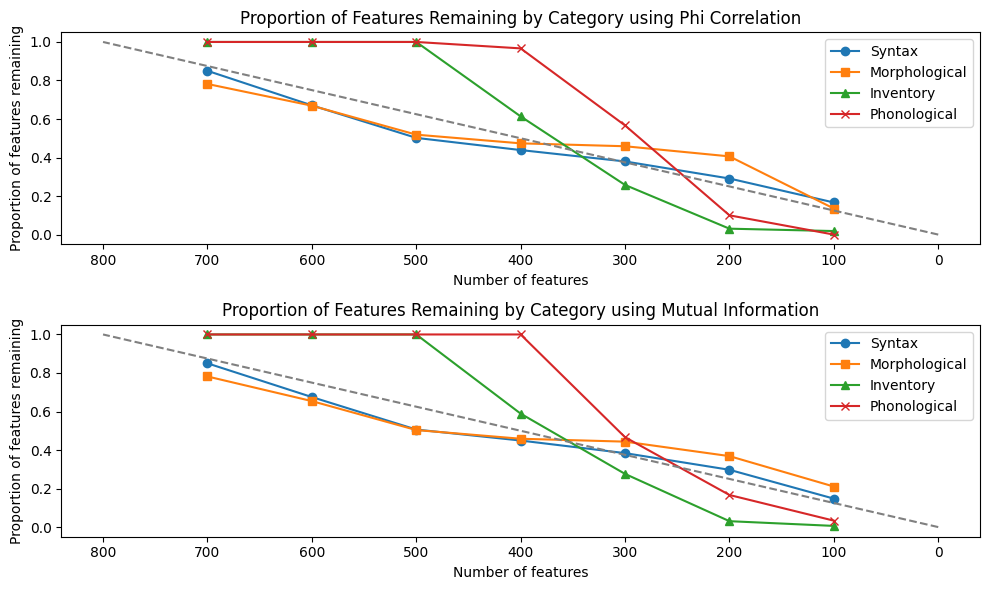

In [14]:
# Create Graphs
hueristics = ['phi', 'mi']
names = ['Phi Correlation', 'Mutual Information']

fig, ax = plt.subplots(2, figsize=(10, 6))

for i, hueristic in enumerate(hueristics):
    features: dict[list[float]] = {
        'syntax': [],
        'morphological': [],
        'inventory': [], 
        'phonological': []
    }

    # Take the top k features for k = 100, 200, ..., 700
    for k in range(100, 701, 100):
        df: pd.DataFrame = pd.read_csv(f'selection_result/ant_{hueristic}_{k}.csv', index_col=0)
        
        n_syntax, n_morphological, n_inventory, n_phonological = count_features(df)
        features['syntax'].append(n_syntax / base_syntax)
        features['morphological'].append(n_morphological / base_morphological)
        features['inventory'].append(n_inventory / base_inventory)
        features['phonological'].append(n_phonological / base_phonological)

    ax[i].plot(range(100, 701, 100), features['syntax'], label='Syntax', marker='o')
    ax[i].plot(range(100, 701, 100), features['morphological'], label='Morphological', marker='s')
    ax[i].plot(range(100, 701, 100), features['inventory'], label='Inventory', marker='^')
    ax[i].plot(range(100, 701, 100), features['phonological'], label='Phonological', marker='x')
    ax[i].plot([0, 800], [0, 1], '--', color='gray')
    ax[i].set_title(f'Proportion of Features Remaining by Category using {names[i]}')
    ax[i].set_xlabel('Number of features')
    ax[i].invert_xaxis()
    ax[i].set_ylabel('Proportion of features remaining')
    ax[i].legend()

plt.tight_layout()
plt.show()